# Gaussian Physics Explained (2D)

This notebook mirrors the 1D exploration but uses the 2D Gaussian action
implementation from `temgym_core.gaussian_action2D`. The scenes here show how
thin lenses, aberrated lenses, and smooth apertures sculpt both the amplitude
and phase of a paraxial Gaussian packet.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

from temgym_core.gaussian_action2D import (
    GaussianRay2D,
    ABCDPropagator2D,
    ThinLens2D,
    AberratedLens2D,
    SigmoidAperture2D,
    run_to_end,
)

from temgym_core.utils import FresnelPropagator

jax.config.update("jax_enable_x64", True)
%matplotlib inline

/tmp/ipykernel_2515567/3513168233.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


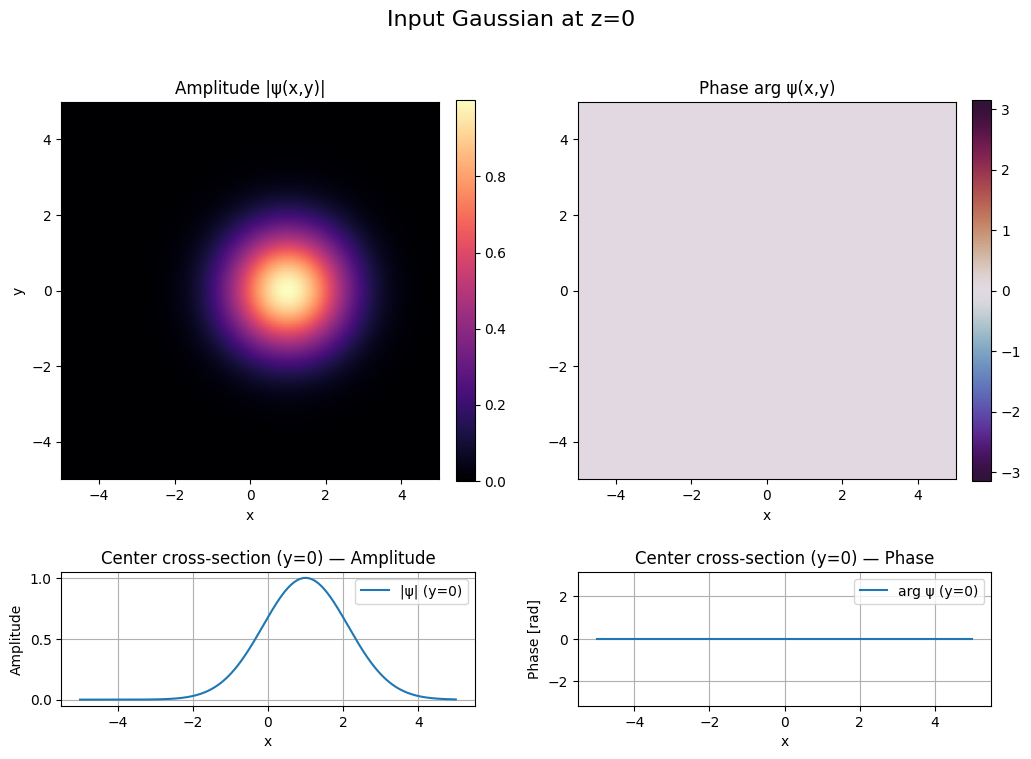

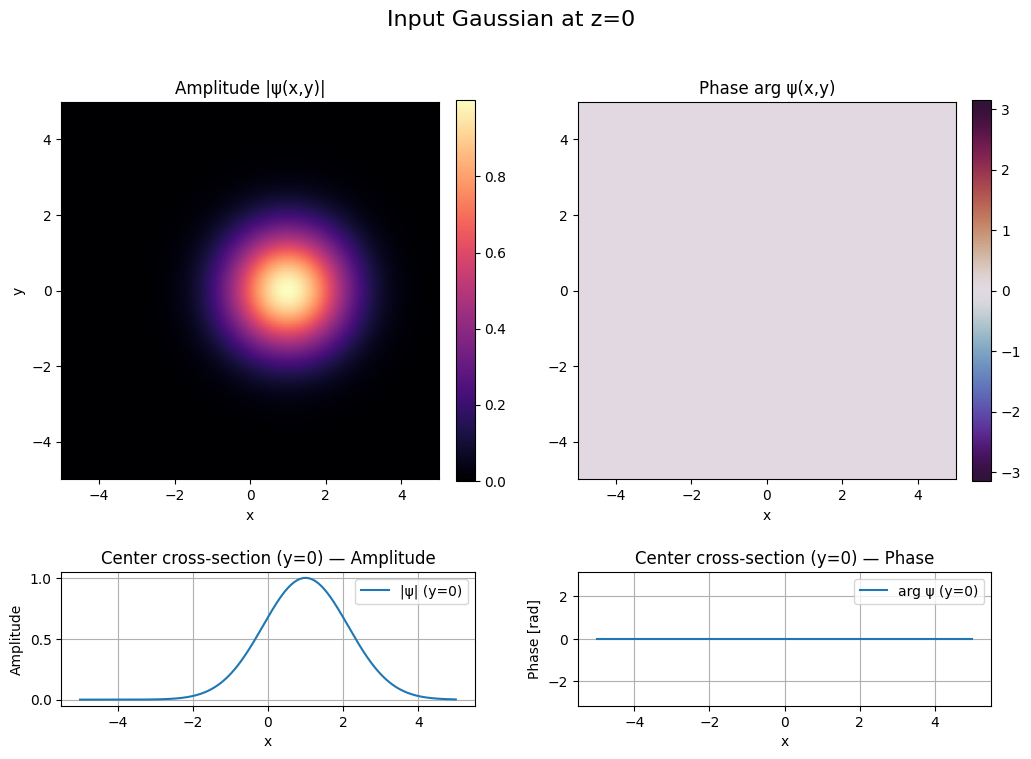

In [ ]:
# Grid utilities shared across examples
extent = (-5.0, 5.0)
N = 256
x = jnp.linspace(extent[0], extent[1], N)
y = jnp.linspace(extent[0], extent[1], N)
X, Y = jnp.meshgrid(x, y, indexing="xy")
XY = jnp.stack([X, Y], axis=-1)
XY_ravel = [X.ravel(), Y.ravel()]

wavelength = 0.5
k0 = 2.0 * jnp.pi / wavelength

def plot_amplitude_phase_with_cross(field, *, ref=None, suptitle="", cmap_phase="twilight_shifted"):
    """Render amplitude and wrapped phase of a complex field on the XY grid and
    include 1D cross-sections through the center (y=0 row) for amplitude and phase.
    If `ref` is provided, the cross-sections show both field and ref for comparison.
    """
    arr = np.asarray(field)
    amp = np.abs(arr)
    phase = np.angle(arr)

    center_idx = N // 2  # central row (y ~ 0)
    x_line = np.asarray(x)

    if ref is None:
        fig = plt.figure(figsize=(12, 8))
        gs = fig.add_gridspec(2, 2, height_ratios=[3, 1], hspace=0.3, wspace=0.25)

        ax_amp = fig.add_subplot(gs[0, 0])
        ax_phase = fig.add_subplot(gs[0, 1])
        ax_amp_cs = fig.add_subplot(gs[1, 0])
        ax_phase_cs = fig.add_subplot(gs[1, 1])

        im_amp = ax_amp.imshow(
            amp,
            extent=[extent[0], extent[1], extent[0], extent[1]],
            origin="lower",
            cmap="magma",
        )
        ax_amp.set_title("Amplitude |ψ(x,y)|")
        ax_amp.set_xlabel("x")
        ax_amp.set_ylabel("y")
        fig.colorbar(im_amp, ax=ax_amp, fraction=0.046, pad=0.04)

        im_phase = ax_phase.imshow(
            phase,
            extent=[extent[0], extent[1], extent[0], extent[1]],
            origin="lower",
            cmap=cmap_phase,
            vmin=-np.pi,
            vmax=np.pi,
        )
        ax_phase.set_title("Phase arg ψ(x,y)")
        ax_phase.set_xlabel("x")
        fig.colorbar(im_phase, ax=ax_phase, fraction=0.046, pad=0.04)

        # cross-sections (center row)
        ax_amp_cs.plot(x_line, amp[center_idx, :], label="|ψ| (y=0)")
        ax_amp_cs.set_xlabel("x")
        ax_amp_cs.set_ylabel("Amplitude")
        ax_amp_cs.set_title("Center cross-section (y=0) — Amplitude")
        ax_amp_cs.grid(True)
        ax_amp_cs.legend()

        ax_phase_cs.plot(x_line, phase[center_idx, :], label="arg ψ (y=0)")
        ax_phase_cs.set_xlabel("x")
        ax_phase_cs.set_ylabel("Phase [rad]")
        ax_phase_cs.set_title("Center cross-section (y=0) — Phase")
        ax_phase_cs.set_ylim(-np.pi, np.pi)
        ax_phase_cs.grid(True)
        ax_phase_cs.legend()
    else:
        ref_arr = np.asarray(ref)
        amp_ref = np.abs(ref_arr)
        phase_ref = np.angle(ref_arr)

        # wrapped phase difference in [-pi, pi]
        phase_diff = np.angle(np.exp(1j * (phase - phase_ref)))
        amp_diff = amp - amp_ref

        fig = plt.figure(figsize=(18, 10))
        gs = fig.add_gridspec(2, 4, height_ratios=[3, 1], hspace=0.35, wspace=0.25)

        ax_amp = fig.add_subplot(gs[0, 0])
        ax_phase = fig.add_subplot(gs[0, 1])
        ax_amp_diff = fig.add_subplot(gs[0, 2])
        ax_phase_diff = fig.add_subplot(gs[0, 3])

        ax_amp_cs = fig.add_subplot(gs[1, 0:2])
        ax_phase_cs = fig.add_subplot(gs[1, 2:4])

        im_amp = ax_amp.imshow(
            amp,
            extent=[extent[0], extent[1], extent[0], extent[1]],
            origin="lower",
            cmap="magma",
        )
        ax_amp.set_title("Amplitude |ψ(x,y)|")
        ax_amp.set_xlabel("x")
        ax_amp.set_ylabel("y")
        fig.colorbar(im_amp, ax=ax_amp, fraction=0.046, pad=0.04)

        im_phase = ax_phase.imshow(
            phase,
            extent=[extent[0], extent[1], extent[0], extent[1]],
            origin="lower",
            cmap=cmap_phase,
            vmin=-np.pi,
            vmax=np.pi,
        )
        ax_phase.set_title("Phase arg ψ(x,y)")
        ax_phase.set_xlabel("x")
        fig.colorbar(im_phase, ax=ax_phase, fraction=0.046, pad=0.04)

        maxabs = np.max(np.abs(amp_diff))
        im_amp_diff = ax_amp_diff.imshow(
            amp_diff,
            extent=[extent[0], extent[1], extent[0], extent[1]],
            origin="lower",
            cmap="seismic",
            vmin=-maxabs,
            vmax=maxabs,
        )
        ax_amp_diff.set_title("Amplitude difference\n|ψ| - |ψ_ref|")
        ax_amp_diff.set_xlabel("x")
        fig.colorbar(im_amp_diff, ax=ax_amp_diff, fraction=0.046, pad=0.04)

        im_phase_diff = ax_phase_diff.imshow(
            phase_diff,
            extent=[extent[0], extent[1], extent[0], extent[1]],
            origin="lower",
            cmap=cmap_phase,
            vmin=-np.pi,
            vmax=np.pi,
        )
        ax_phase_diff.set_title("Wrapped phase difference\narg(ψ/ψ_ref)")
        ax_phase_diff.set_xlabel("x")
        fig.colorbar(im_phase_diff, ax=ax_phase_diff, fraction=0.046, pad=0.04)

        # cross-sections (center row): amplitude and amplitude ref
        ax_amp_cs.plot(x_line, amp[center_idx, :], label="|ψ| (y=0)")
        ax_amp_cs.plot(x_line, amp_ref[center_idx, :], linestyle="--", label="|ψ_ref| (y=0)")
        ax_amp_cs.set_xlabel("x")
        ax_amp_cs.set_ylabel("Amplitude")
        ax_amp_cs.set_title("Center cross-section (y=0) — Amplitude")
        ax_amp_cs.grid(True)
        ax_amp_cs.legend()

        # phase cross-section: show wrapped phase and wrapped ref phase (or phase difference)
        ax_phase_cs.plot(x_line, phase[center_idx, :], label="arg ψ (y=0)")
        ax_phase_cs.plot(x_line, phase_ref[center_idx, :], linestyle="--", label="arg ψ_ref (y=0)")
        ax_phase_cs.set_xlabel("x")
        ax_phase_cs.set_ylabel("Phase [rad]")
        ax_phase_cs.set_title("Center cross-section (y=0) — Phase")
        ax_phase_cs.set_ylim(-np.pi, np.pi)
        ax_phase_cs.grid(True)
        ax_phase_cs.legend()

    if suptitle:
        fig.suptitle(suptitle, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    return fig


gaussian_in = GaussianRay2D.make_gaussian(
    x=1,
    y=0.0,
    dx=0.0,
    dy=0.0,
    waist_x=0.8,
    waist_y=0.8,
    k=float(k0),
    z=0.0,
)

plot_amplitude_phase_with_cross(gaussian_in.field(XY), suptitle="Input Gaussian at z=0")

## Example 1 – Thin Lens

Apply a thin lens centred at the origin and inspect the outgoing field.

/tmp/ipykernel_2515567/3513168233.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


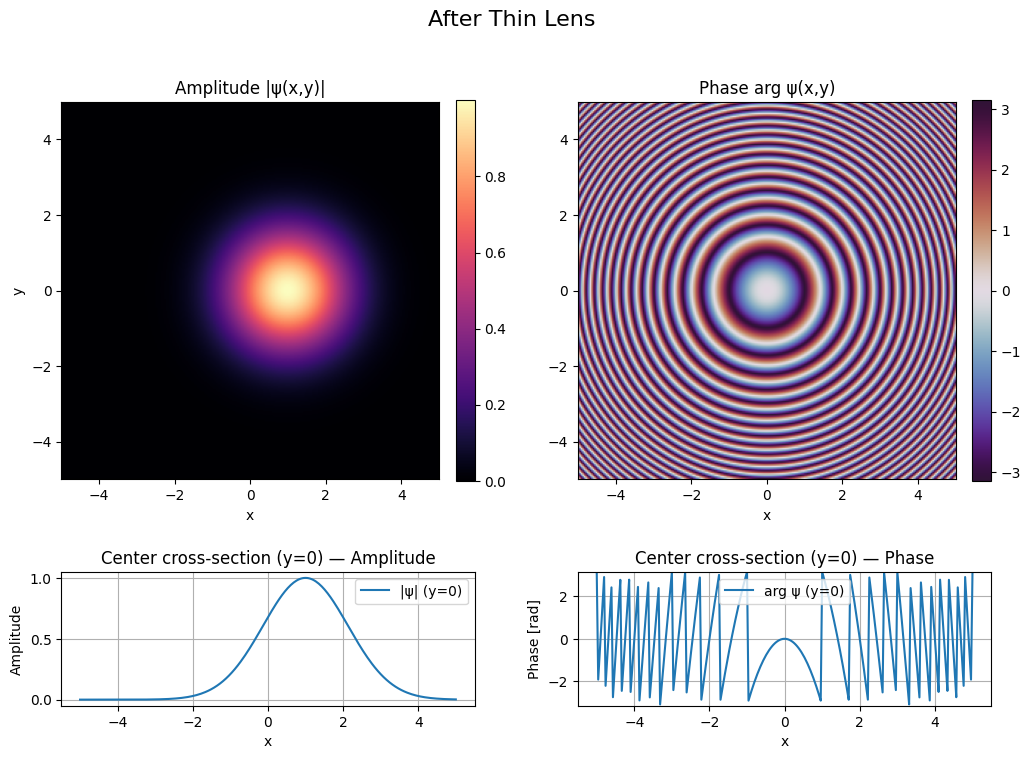

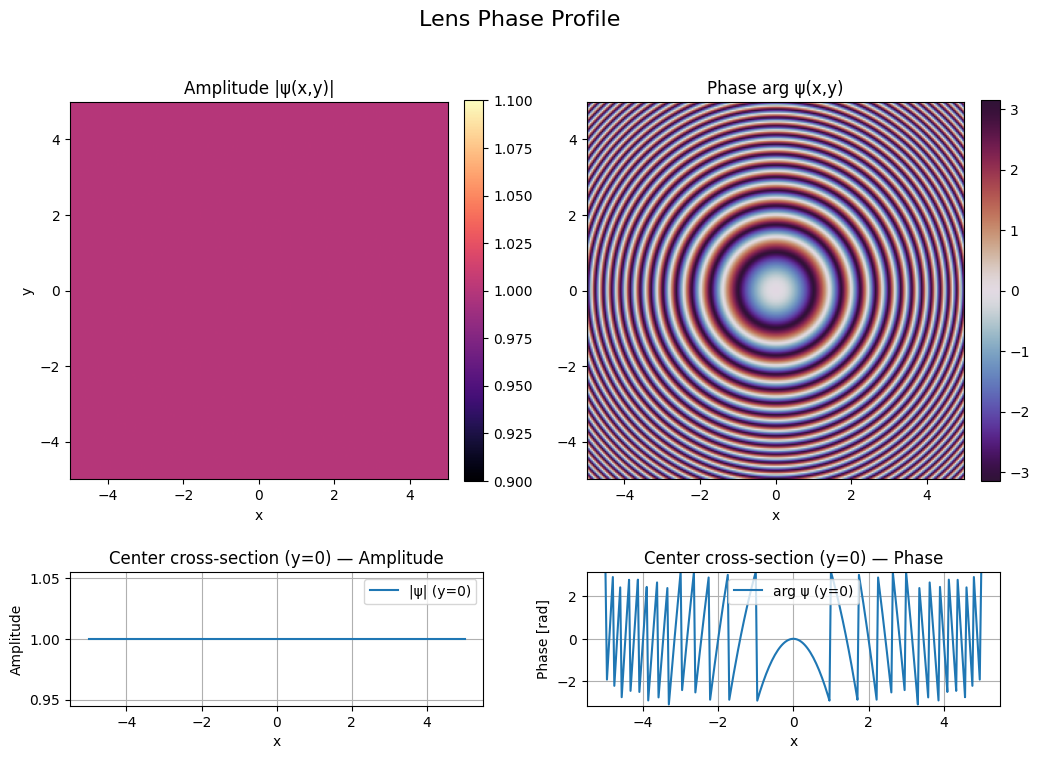

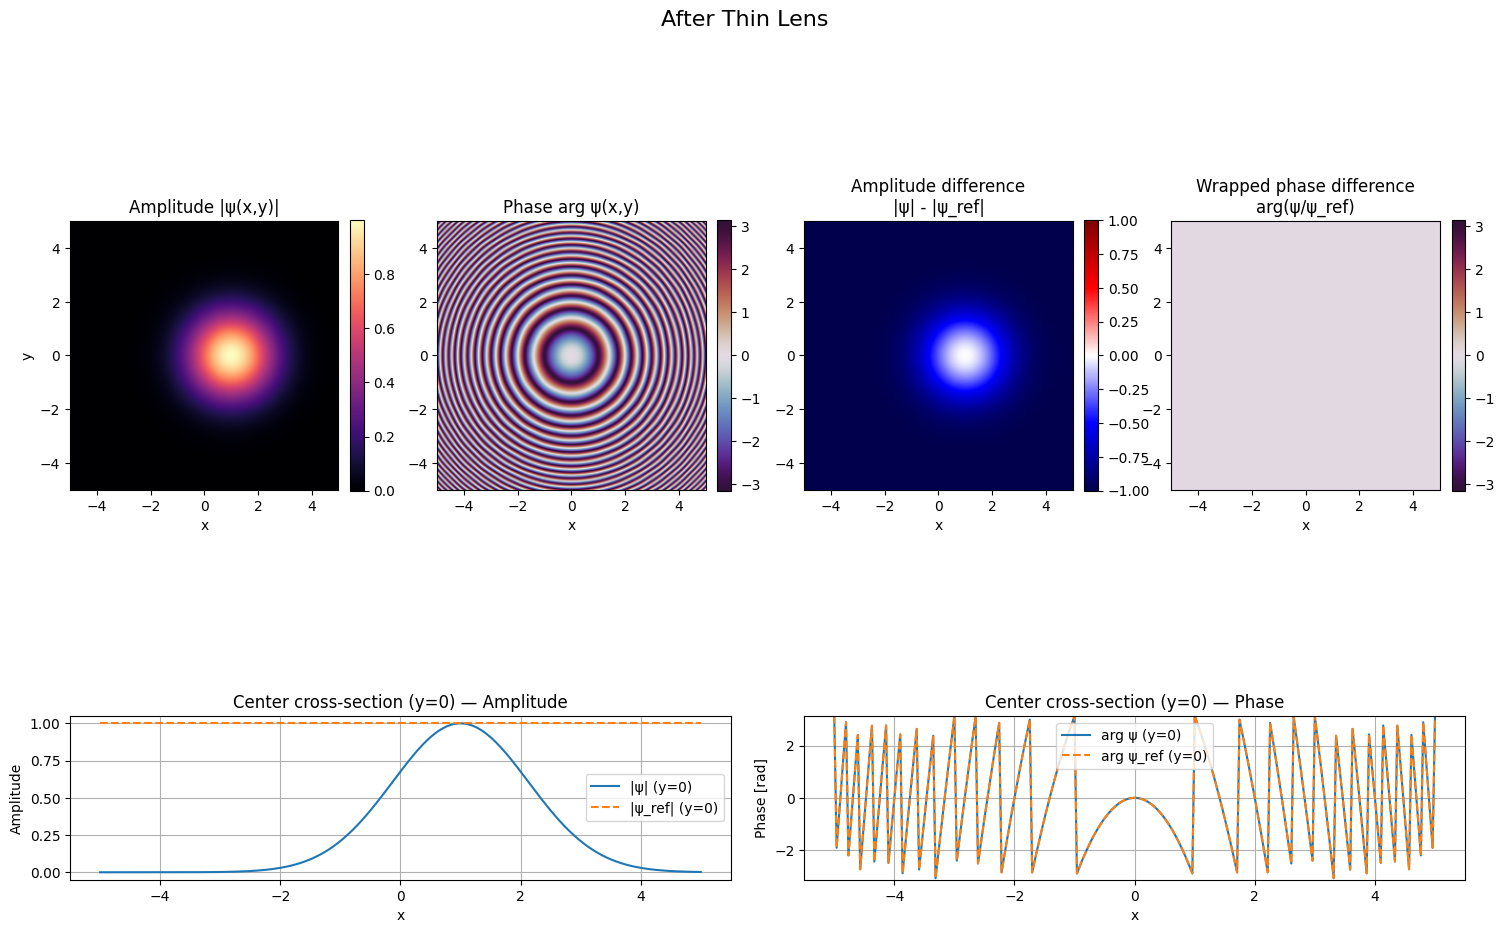

In [3]:
thin_lens = ThinLens2D(focal_length=2.0, z=0.0)
gaussian_after_lens = thin_lens(gaussian_in)

field_lens = gaussian_after_lens.field(XY)
plot_amplitude_phase_with_cross(field_lens, suptitle="After Thin Lens")

XY_ravel = [X.ravel(), Y.ravel()]
lens_phase = jnp.exp(1j * k0 * thin_lens.phase_shift(XY_ravel).reshape(N, N))
plot_amplitude_phase_with_cross(lens_phase, suptitle="Lens Phase Profile")

plot_amplitude_phase_with_cross(field_lens, ref=lens_phase, suptitle="After Thin Lens")
plt.show()


## Example 2 – Aberrated Lens

Introduce low-order radial aberrations to see the phase distortion at the exit plane.

/tmp/ipykernel_2515567/3513168233.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


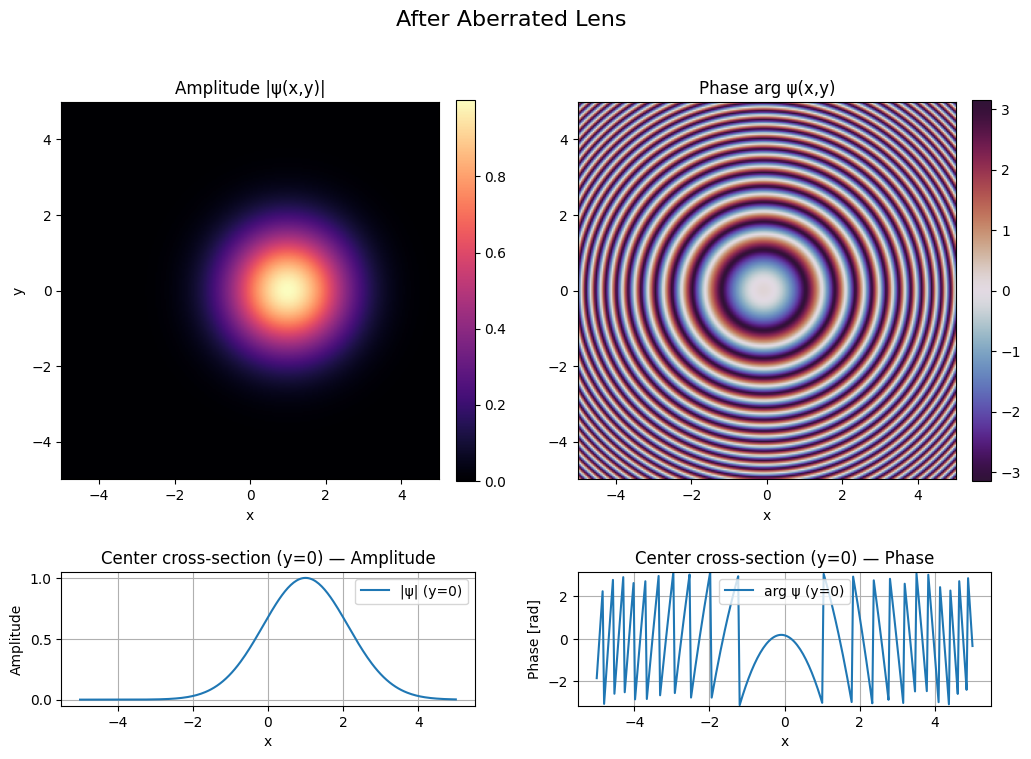

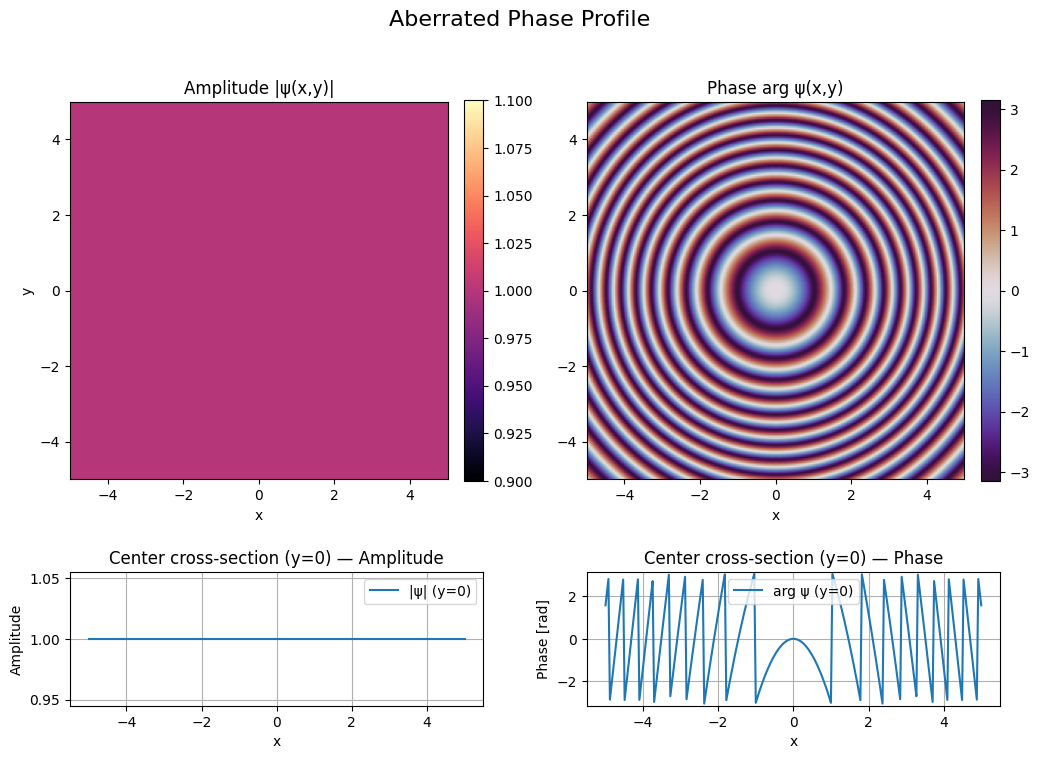

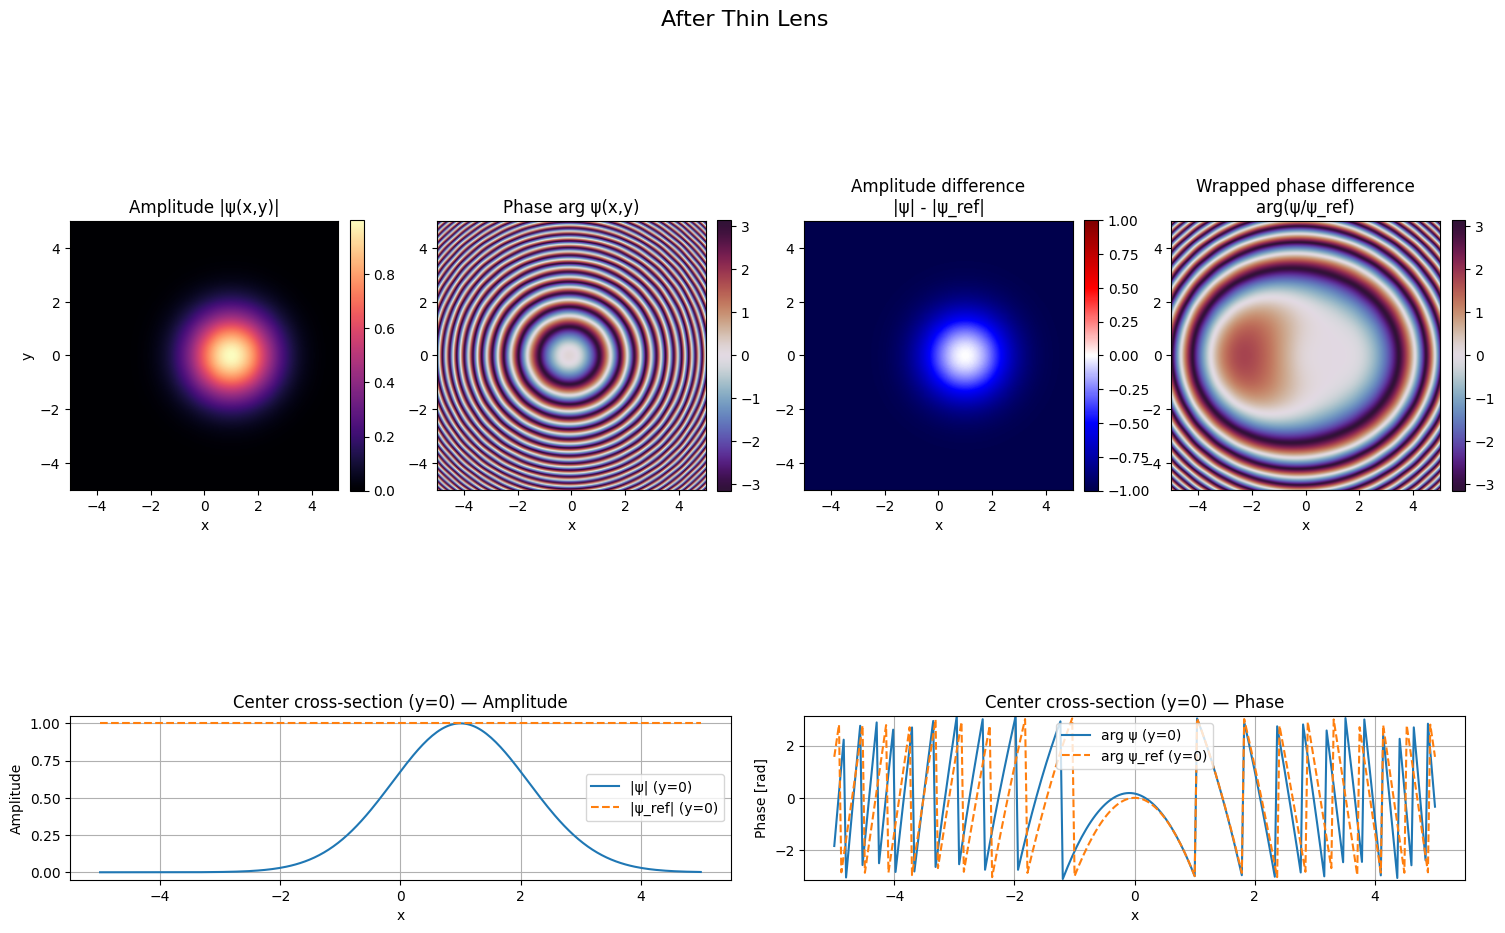

In [4]:
aberrated_lens = AberratedLens2D(
    focal_length=2.0,
    cubic_coeff=0.01,
    quartic_coeff=0.001,
    z=0.0,
)

gaussian_after_lens = aberrated_lens(gaussian_in)
field_lens = gaussian_after_lens.field(XY)
plot_amplitude_phase_with_cross(field_lens, suptitle="After Aberrated Lens")

aberrated_phase = jnp.exp(1j * k0 * aberrated_lens.phase_shift(XY_ravel).reshape(N, N))
plot_amplitude_phase_with_cross(aberrated_phase, suptitle="Aberrated Phase Profile")

plot_amplitude_phase_with_cross(field_lens, ref=aberrated_phase, suptitle="After Thin Lens")
plt.show()



## Example 3 – Sigmoid Aperture

A soft radial aperture attenuates the beam and shifts the intensity centre.

/tmp/ipykernel_2515567/3513168233.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


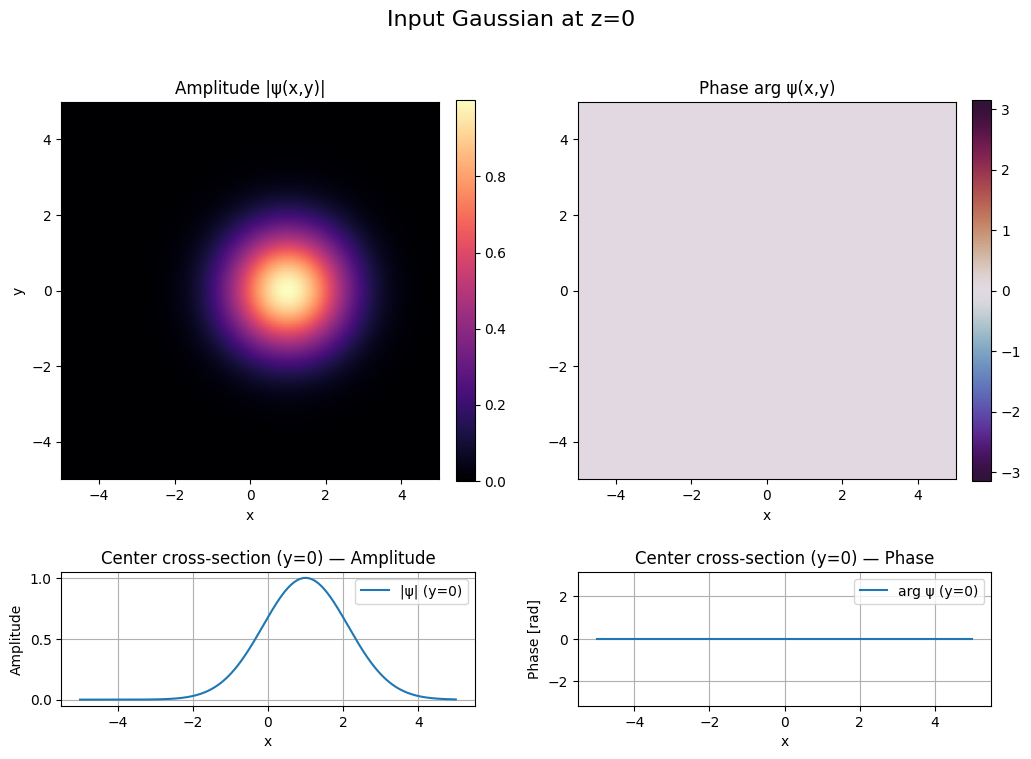

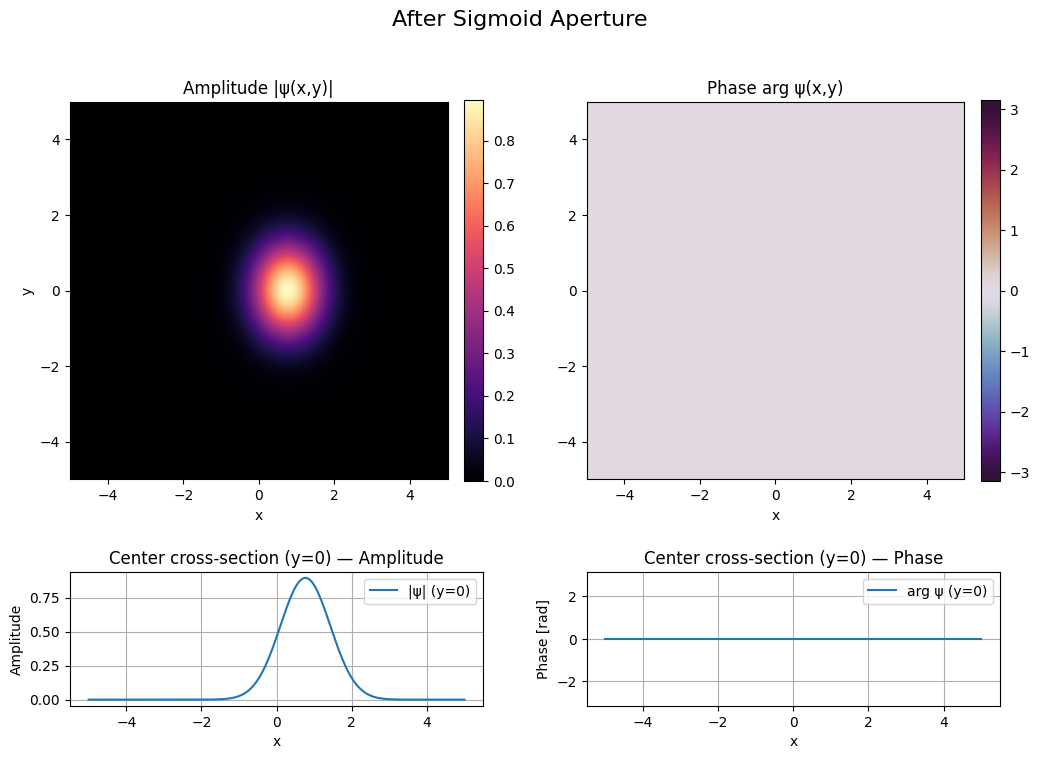

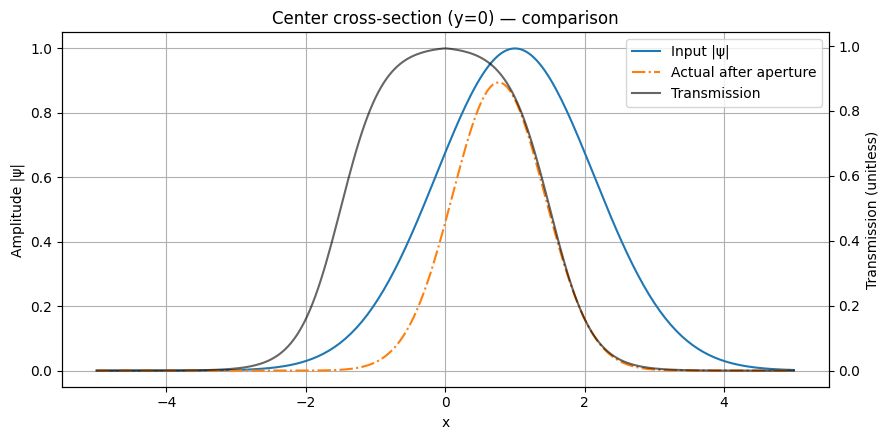

In [5]:
aperture = SigmoidAperture2D(
    radius=1.5,
    width=0.3,
    t_low=0.0,
    t_high=1.0,
    z=0.0,
)

plot_amplitude_phase_with_cross(gaussian_in.field(XY), suptitle="Input Gaussian at z=0")

gaussian_after_aperture = aperture(gaussian_in)
plot_amplitude_phase_with_cross(gaussian_after_aperture.field(XY), suptitle="After Sigmoid Aperture")

# compute transmission on the grid and reshape to (N, N)
transmission = jnp.exp(aperture.log_transmission(XY_ravel)).reshape(N, N)

expected_after_aperture = gaussian_in.field(XY) * transmission

input_amp = np.abs(np.asarray(gaussian_in.field(XY)))
actual_amp = np.abs(np.asarray(gaussian_after_aperture.field(XY)))
transmission_arr = np.asarray(transmission)

center_idx = N // 2  # central row (y ~ 0)
x_line = np.asarray(x)

fig, ax = plt.subplots(figsize=(9, 4.5))
l1, = ax.plot(x_line, input_amp[center_idx, :], label="Input |ψ|")
l3, = ax.plot(
    x_line, actual_amp[center_idx, :], linestyle="-.", label="Actual after aperture"
)

# plot transmission on a secondary axis for clarity
ax2 = ax.twinx()
l4, = ax2.plot(x_line, transmission_arr[center_idx, :], color="k", alpha=0.6, label="Transmission")
ax.set_xlabel("x")
ax.set_ylabel("Amplitude |ψ|")
ax2.set_ylabel("Transmission (unitless)")
ax.set_title("Center cross-section (y=0) — comparison")
ax.grid(True)

# combined legend
lines = [l1, l3, l4]
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, loc="upper right")

plt.tight_layout()
plt.show()
plt.show()

## Example 4 - Free Space Propagation testing

/tmp/ipykernel_2515567/3513168233.py:161: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


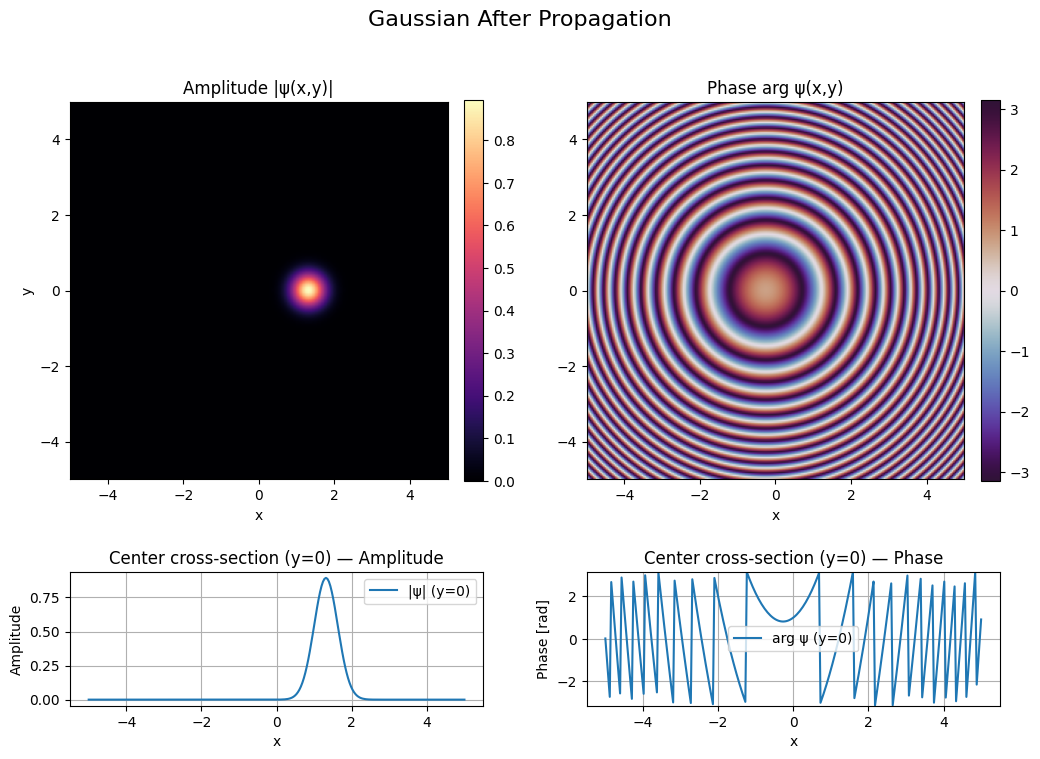

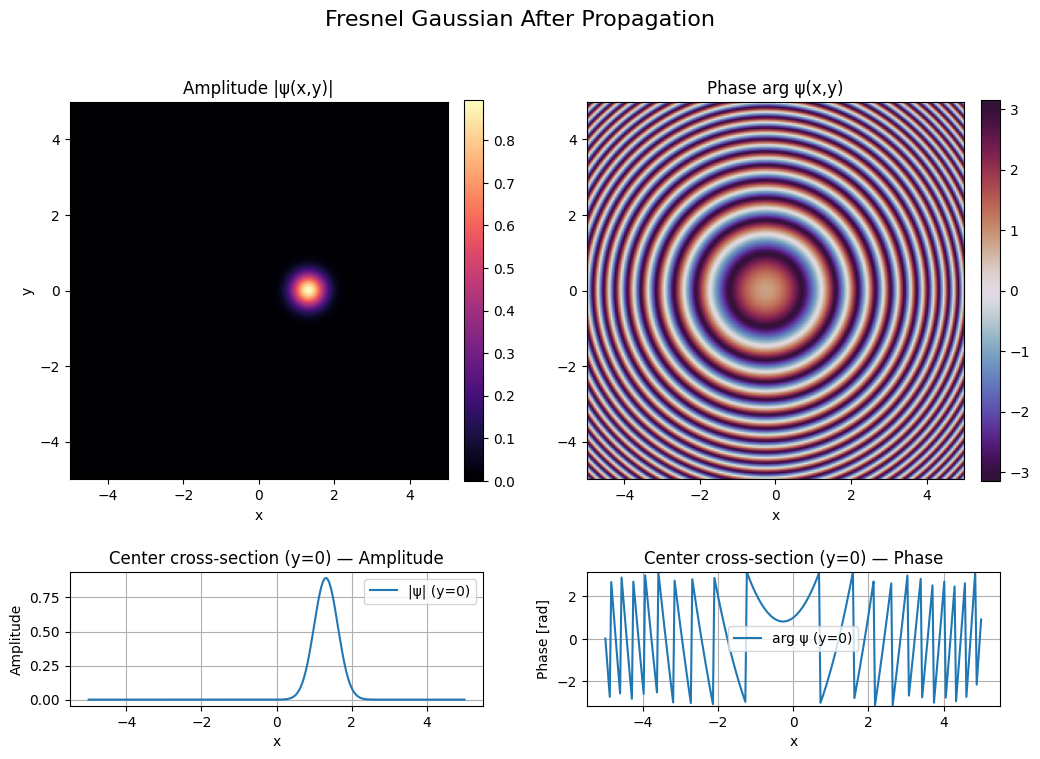

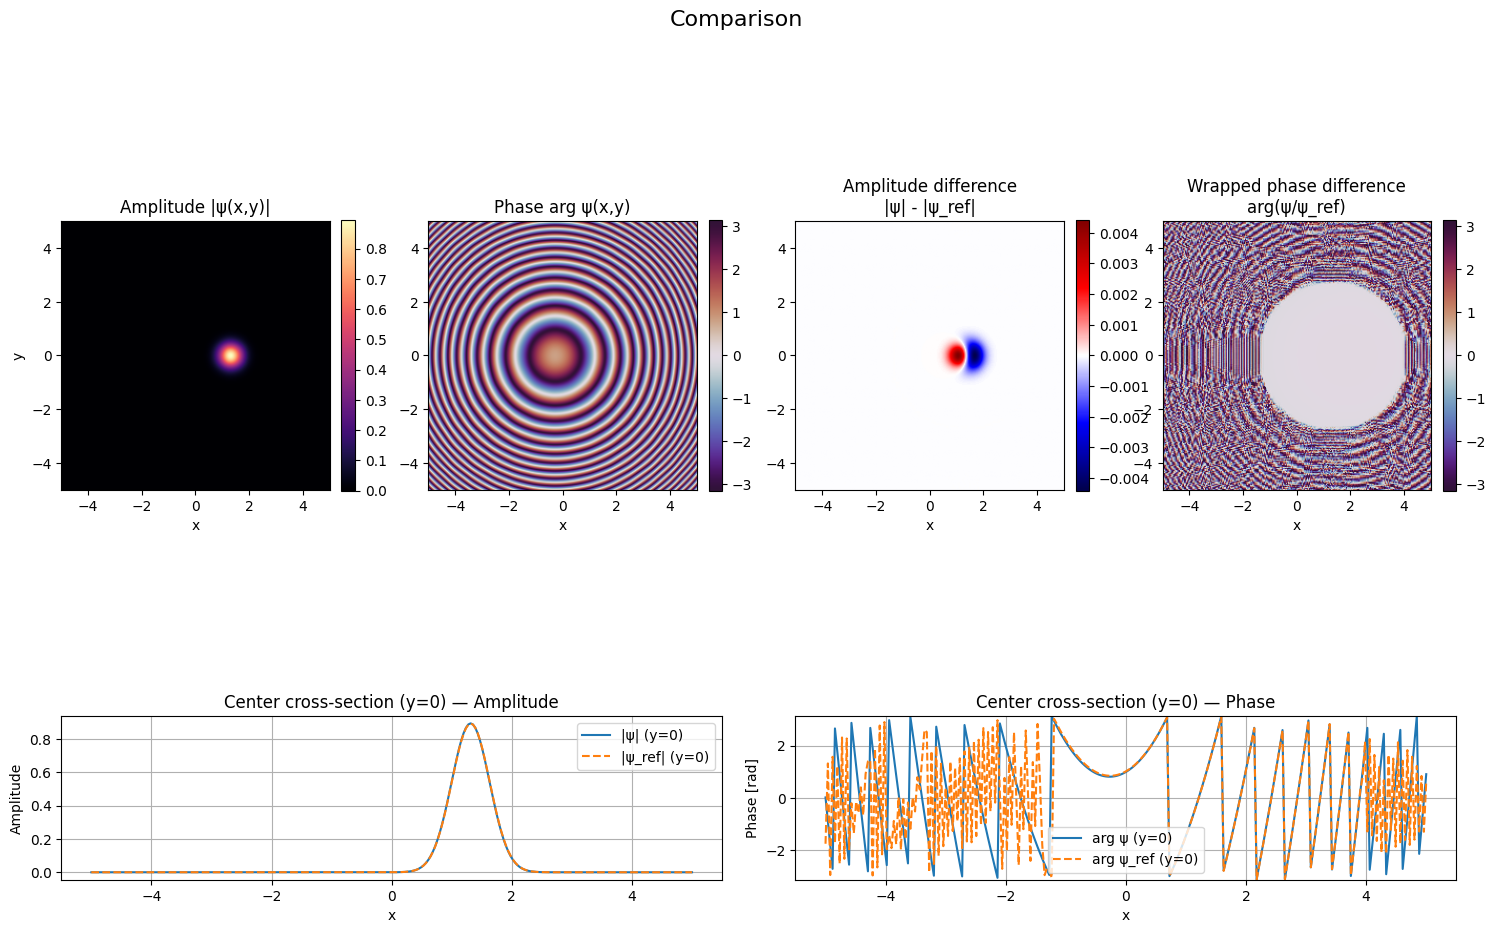

In [6]:
gaussian_in = GaussianRay2D.make_gaussian(
    x=1,
    y=0.0,
    dx=0.05,
    dy=0.0,
    waist_x=0.2,
    waist_y=0.2,
    k=float(k0),
    z=0.0,
)

z=0.5
propagator = ABCDPropagator2D.free_space(z)
gaussian_after_propagation = propagator(gaussian_in)

plot_amplitude_phase_with_cross(
    gaussian_after_propagation.field(XY), suptitle="Gaussian After Propagation"
)

L = jnp.max(x) - jnp.min(x)
fresnel_gaussian_after_propagation = FresnelPropagator(gaussian_in.field(XY), L, wavelength, z)

plot_amplitude_phase_with_cross(
    gaussian_after_propagation.field(XY), suptitle="Fresnel Gaussian After Propagation"
)

plot_amplitude_phase_with_cross(
    gaussian_after_propagation.field(XY), ref=fresnel_gaussian_after_propagation, suptitle="Comparison"
)
plt.show()

## Example 5 - Lens Propagation Testing

10.0


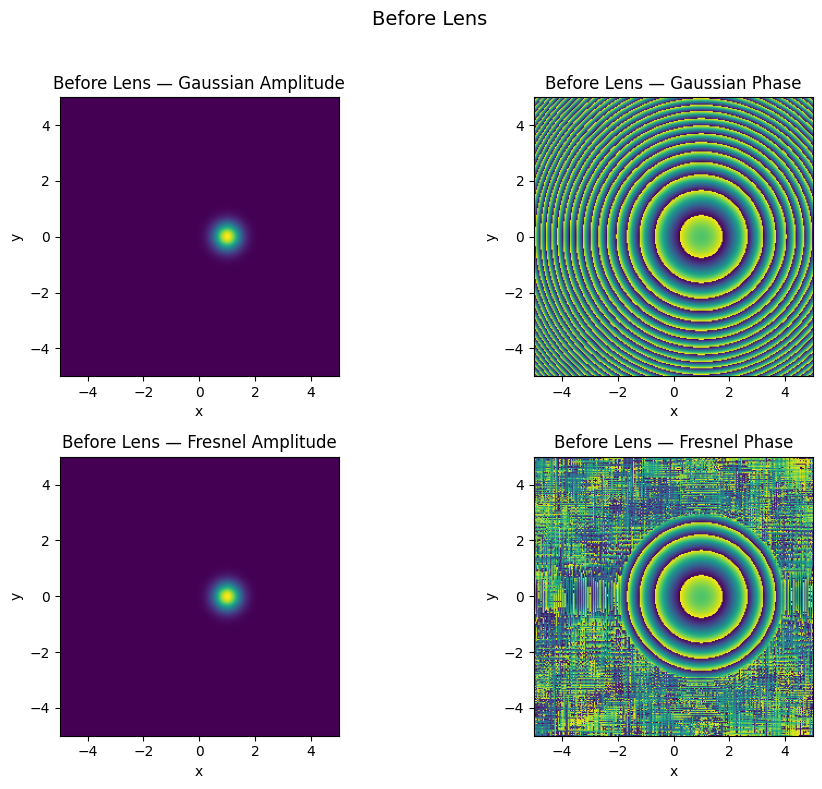

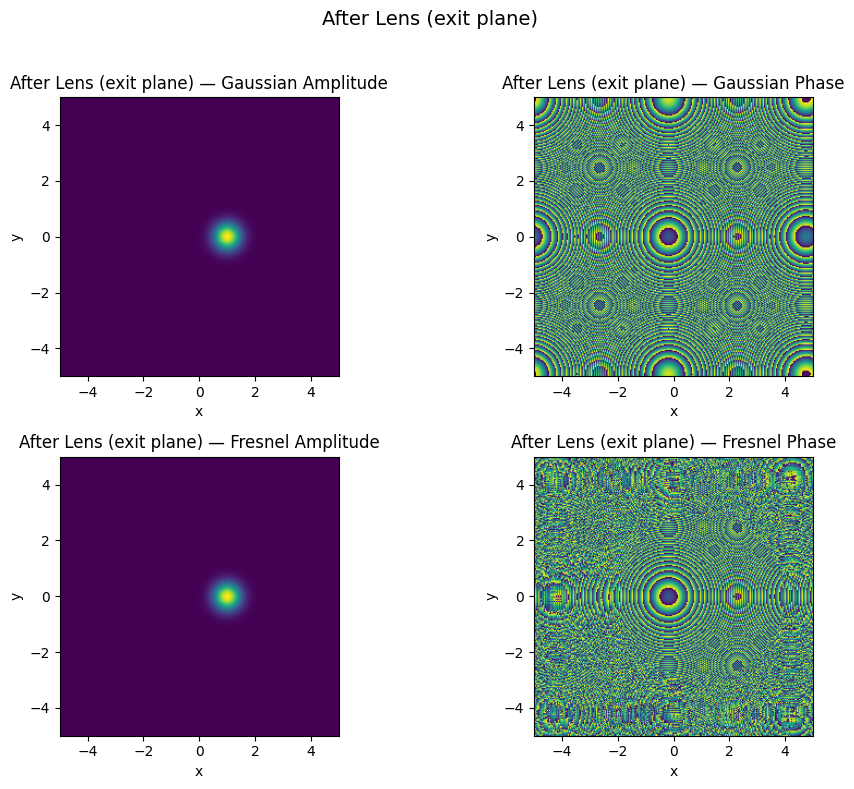

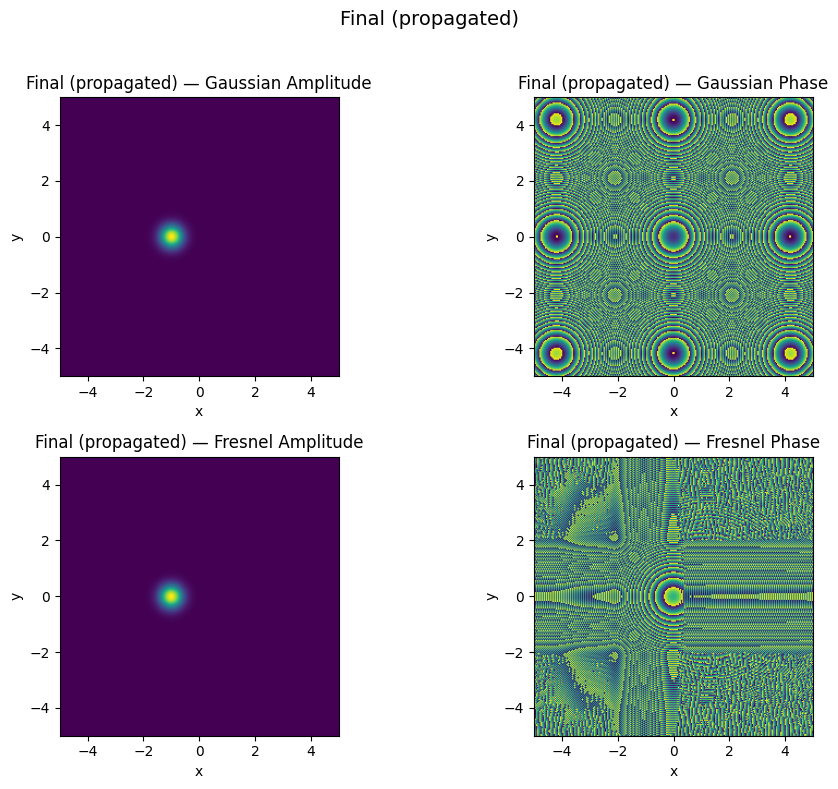

In [ ]:
gaussian_in = GaussianRay2D.make_gaussian(
    x=1,
    y=0.0,
    dx=0.00,
    dy=0.0,
    waist_x=0.2,
    waist_y=0.2,
    k=float(k0),
    z=0.0,
)


print(L)
f = 0.33
M = -1
z1 = f * (1 - 1 / M)
z2 = f * (1 - M)
z1 = abs(z1)
z2 = abs(z2)

A1 = jnp.eye(2)
B1 = jnp.eye(2) * z1
C1 = jnp.eye(2) * 0.0
D1 = jnp.eye(2)

A2 = jnp.eye(2)
B2 = jnp.eye(2) * 0.0
C2 = jnp.eye(2) * -1.0 / f
D2 = jnp.eye(2)

A3 = jnp.eye(2)
B3 = jnp.eye(2) * z2
C3 = jnp.eye(2) * 0.0
D3 = jnp.eye(2)

before_lens_gaussian = ABCDPropagator2D(A=A1, B=B1, C=C1, D=D1, L=z1)(gaussian_in)
after_lens_gaussian = ABCDPropagator2D(A=A2, B=B2, C=C2, D=D2, L=0.0)(before_lens_gaussian)
final_gaussian = ABCDPropagator2D(A=A3, B=B3, C=C3, D=D3, L=z2)(after_lens_gaussian)

fresnel_before_lens = FresnelPropagator(gaussian_in.field(XY), L, wavelength, z1)
fresnel_after_lens = fresnel_before_lens * jnp.exp(-1j * k0 * (X**2 + Y**2) / (2 * f))
fresnel_final = FresnelPropagator(fresnel_after_lens, L, wavelength, z2)

stages = [
    ("Before Lens", before_lens_gaussian, fresnel_before_lens),
    ("After Lens (exit plane)", after_lens_gaussian, fresnel_after_lens),
    ("Final (propagated)", final_gaussian, fresnel_final),
]

for title, gaussian_obj, fresnel_arr in stages:
    field = np.asarray(gaussian_obj.field(XY))
    amp = np.abs(field)
    phase = np.angle(field)

    fres = np.asarray(fresnel_arr)
    # ensure fresnel has shape (N, N) -- should already, but reshape defensively if 1D
    if fres.ndim == 1:
        fres = fres.reshape(N, N)
    amp_f = np.abs(fres)
    phase_f = np.angle(fres)

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    axs[0, 0].imshow(
        amp,
        extent=[extent[0], extent[1], extent[0], extent[1]],
        origin="lower",
    )
    axs[0, 0].set_title(f"{title} — Gaussian Amplitude")

    axs[0, 1].imshow(
        phase,
        extent=[extent[0], extent[1], extent[0], extent[1]],
        origin="lower",
        vmin=-np.pi,
        vmax=np.pi,
    )
    axs[0, 1].set_title(f"{title} — Gaussian Phase")

    axs[1, 0].imshow(
        amp_f,
        extent=[extent[0], extent[1], extent[0], extent[1]],
        origin="lower",
    )
    axs[1, 0].set_title(f"{title} — Fresnel Amplitude")

    axs[1, 1].imshow(
        phase_f,
        extent=[extent[0], extent[1], extent[0], extent[1]],
        origin="lower",
        vmin=-np.pi,
        vmax=np.pi,
    )
    axs[1, 1].set_title(f"{title} — Fresnel Phase")

    for ax in axs.ravel():
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
